In [ ]:
import pandas as pd
df=pd.read_csv("/content/Salary_Data.csv")
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [ ]:
#Reading the dataset
df=pd.read_csv("/content/Salary_Data.csv")
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [ ]:
#slice the dataset as descriptive (independent) and target variable(dependent)
x=df.iloc[:,0:1].values
y=df.iloc[:,-1].values
print(x)
print(y)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]
[ 39343.  46205.  37731.  43525.  39891.  56642.  60150.  54445.  64445.
  57189.  63218.  55794.  56957.  57081.  61111.  67938.  66029.  83088.
  81363.  93940.  91738.  98273. 101302. 113812. 109431. 105582. 116969.
 112635. 122391. 121872.]


In [ ]:
#Splitting the dataset into training set and testing set
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=1/3,random_state=0)

In [ ]:
print(df.shape)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(30, 2)
(20, 1)
(10, 1)
(20,)
(10,)


In [ ]:
#calculate the mean values of input and output
import numpy as np
x_mean=np.mean(x_train)
y_mean=np.mean(y_train)
print(x_mean)
print(y_mean)

4.7299999999999995
71022.5


In [ ]:
 #calculate intercept and coefficient
 n= len(x_train)
 num,den=0,0

 for i in range(n):
  num+=(x_train[i]-x_mean)*(y_train[i]-y_mean)
  den+=(x_train[i]-x_mean)**2
 b1=num/den
 b0=y_mean-(b1*x_mean)
 print('b1=',b1)
 print('y-intercept,b0=',b0)

b1= [9345.94244312]
y-intercept,b0= [26816.19224403]


In [ ]:
 #predicting result on test dataset
 y_pred_code=b0+b1*x_test
 print( y_pred_code)

[[ 40835.10590871]
 [123079.39940819]
 [ 65134.55626083]
 [ 63265.36777221]
 [115602.64545369]
 [108125.8914992 ]
 [116537.23969801]
 [ 64199.96201652]
 [ 76349.68719258]
 [100649.1375447 ]]


In [ ]:
print(y_test)

[ 37731. 122391.  57081.  63218. 116969. 109431. 112635.  55794.  83088.
 101302.]


In [ ]:
#mean square error
n1=len(y_test)
mse=0
for i in range(n1):
  mse+=(y_test[i]- y_pred_code[i])**2
mse=mse/n1
print(mse)


[21026037.3295113]


In [ ]:
#root mean square error
rmse=np.sqrt(mse)
print(rmse)

[4585.41572047]


In [ ]:
#Machine learning algorithm

#Create an object of the algorithm/model
from sklearn.linear_model import LinearRegression
reg=LinearRegression()

In [ ]:
#Train the model
reg.fit(x_train,y_train)

LinearRegression()

In [ ]:
#predict the model on testing dataset
y_pred=reg.predict(x_test)
print(y_pred)

[ 40835.10590871 123079.39940819  65134.55626083  63265.36777221
 115602.64545369 108125.8914992  116537.23969801  64199.96201652
  76349.68719258 100649.1375447 ]


In [ ]:
#calculate the intercept and coefficient
print("Intercept",reg.intercept_)
print("Coefficient",reg.coef_)

Intercept 26816.192244031183
Coefficient [9345.94244312]


In [ ]:
#Evaluation metrics
from sklearn import metrics
print("Mean absolute error:")
print(metrics.mean_absolute_error(y_test,y_pred))

Mean absolute error:
3426.4269374307078


In [ ]:
#Evaluation metrics
from sklearn import metrics
print("Mean absolute error:",metrics.mean_absolute_error(y_test,y_pred))
print("Mean square error:",metrics.mean_absolute_error(y_test,y_pred))
print("Root mean square:",np.sqrt(metrics.mean_absolute_error(y_test,y_pred)))

Mean absolute error: 3426.4269374307078
Mean square error: 3426.4269374307078
Root mean square: 58.535689433291104


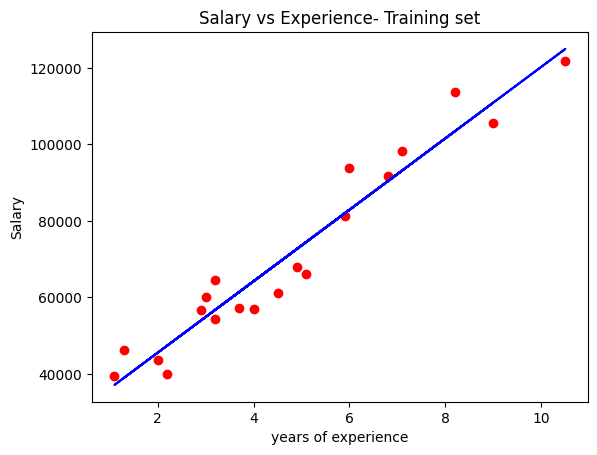

In [ ]:
#Visualization
import matplotlib.pyplot as plt
plt.scatter(x_train,y_train,color='red')
plt.plot(x_train,reg.predict(x_train),color='blue')
plt.title('Salary vs Experience- Training set')
plt.xlabel('years of experience')
plt.ylabel('Salary')
plt.show()

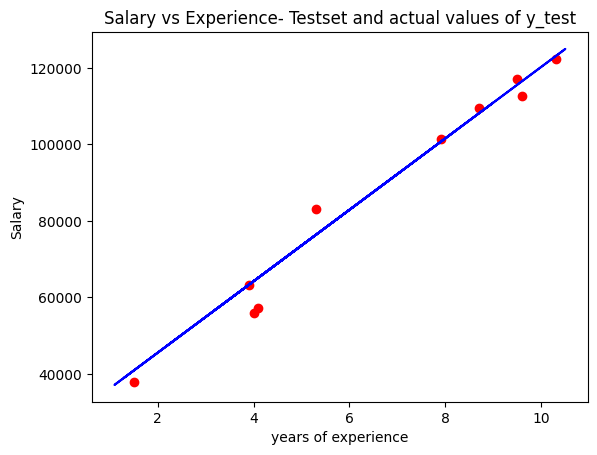

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x_test,y_test,color='red')
plt.plot(x_train,reg.predict(x_train),color='blue')
plt.title('Salary vs Experience- Testset and actual values of y_test')
plt.xlabel('years of experience')
plt.ylabel('Salary')
plt.show()

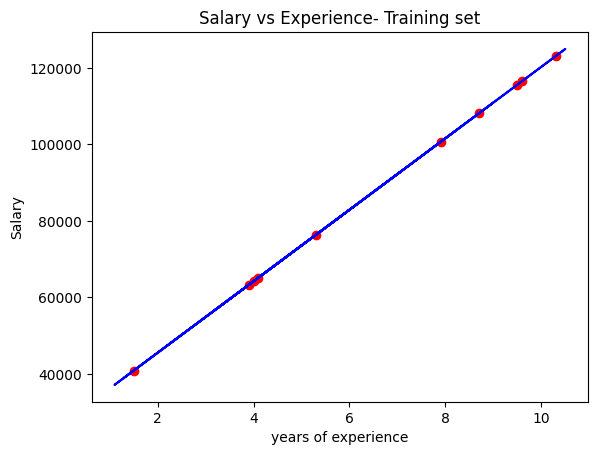

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x_test,y_pred,color='red')
plt.plot(x_train,reg.predict(x_train),color='blue')
plt.title('Salary vs Experience- Training set')
plt.xlabel('years of experience')
plt.ylabel('Salary')
plt.show()

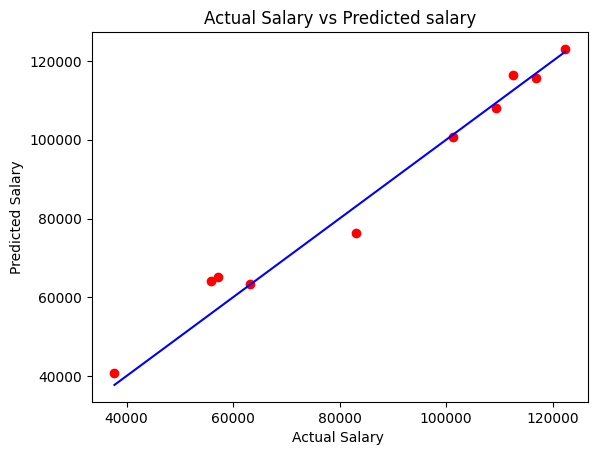

In [ ]:
#Visualization
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred,color='red')
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='blue')
plt.title('Actual Salary vs Predicted salary')
plt.xlabel('Actual Salary ')
plt.ylabel('Predicted Salary')
plt.show()